# K-Means; Some background
Consider the set
 $D = \{ {\bf x}_{1}, {\bf x}_{2}, \cdots, {\bf x}_{N}) \} $, where each ${\bf x}_i \in \mathbb{R}^d$ is a $d$ dimensional feature vector. The goal is to find $K$ clusters that with cluster centers $ \{ {\bf x}^{*c}_{1}, {\bf x}^{*c}_{2}, \cdots, {\bf x}^{*c}_{K}\} $ that can represent this data set so that the following loss function is minimized
$$
J=\frac{1}{N} \sum_{i=1}^N \underset{j}{min} \| {\bf x}_i - {\bf x}_j^c\|^2
$$

The cluster centers are then found using the following
 $$
 \begin{align}
 \{ {\bf x}^{*c}_{1}, {\bf x}^{*c}_{2}, \cdots, {\bf x}^{*c}_{K}\}& = \underset{\{ {\bf x}^c_{1}, {\bf x}^c_{2}, \cdots, {\bf x}^c_{K}\}}{argmin} ~~  \frac{1}{N} \sum_{i=1}^N \underset{j}{min} \| {\bf x}_i - {\bf x}_j^c\|^2 \\
 \end{align}
 $$   

 Unfortunately this loss function is not convex so depending your initial condition and your optimization strategy, the minimum you find might be a local minima. Knowing this fact, in most cases, you solve this optimization problem as follows:


1.   Randomly initialize cluster centers  $ \{ {\bf x}^{c}_{1}, {\bf x}^{c}_{2}, \cdots, {\bf x}^{c}_{K}\} $ (typically, you set them to any $K$ distinct feature vectors from $D$)
2.  Find members of cluster sets (for each ${\bf x}_{i}$ select membership to the cluster of the closest ${\bf x}^{*c}_{j}$)
$$
S_{j^*} = \{ {\bf x}_i \in D ~|~ j^* = \underset{j}{argmin} \| {\bf x}_i - {\bf x}_j^c\| \} ~~~ j^*=1, \cdots, K
$$
1.   Find the new cluster centers (just calculate the average of all members of each cluster):
$$
{\bf x}^c_{j^*} \leftarrow  \frac{1} {|S_{j*}|}\sum_{\forall {x}_i\in S_{j*} }{\bf x}_i ~~~~~~~~ j^*= 1, \cdots, K
$$
where $|S_{j*}|$ is the cardinality of $S_{j*}$ ( the number of elements of $S_{j*}$).
2.   Calculate the cost function, now with the new cluster memberships:
$$
J_{new}=\frac{1}{N} \sum_{i=1}^N \underset{j}{min} \| {\bf x}_i - {\bf x}_{j^*}^c\|^2
$$
If the cluster membership does not change from teh last iteration, then stop.  Otherwise go to step 2.



***
***

#Problem 1 [2 points]
Write Python code that implements the K-Means algorithm, as given above, to classify the data.
*   Use $K=5$
*   To reduce the sensitivity to initial conditions, your code should choose several (10) random initial conditions and then select the one that results in minimum total error.
*   Provide the final cost, $J$, and graph the final centroids.


#Problem 2 [3 points]
Repeat what you did in Problem 1, except this time, vary the number of clusters.
*   Use $K=2$, $K=4$, and $K=10$.   
*   To reduce the sensitivity to initial conditions, your code for each case should choose several (10) random initial conditions and then select the one that results in minimum total error.
*   Provide the minimum cost, $J_K$, for $K=2, 4, 10$ and graph the final centroids for each case.

  Use the data that is generated in the following code to test your code.

In [ ]:
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
blob_centers = np.array(
    [[ 0.2,  2],
     [-1.5 ,  2],
     [-3,  1.8],
     [-3,  3],
     [-3,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

In [ ]:
X, y = make_blobs(n_samples=2000, centers=blob_centers,
                  cluster_std=blob_std, random_state=17)

Text(0, 0.5, '$x_2$')

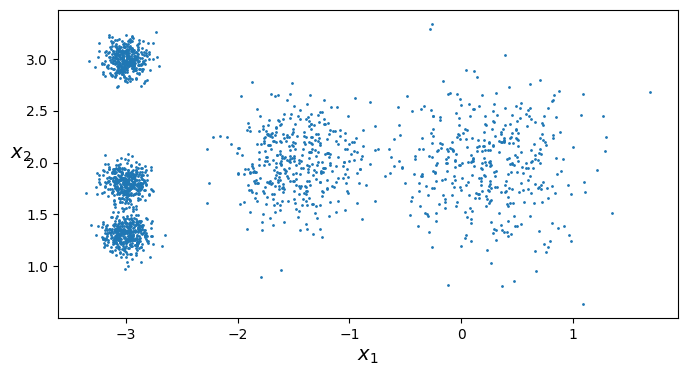

In [ ]:
plt.figure(figsize=(8, 4))
plt.scatter(X[:, 0], X[:, 1],  s=1)
plt.xlabel("$x_1$", fontsize=14)
plt.ylabel("$x_2$", fontsize=14, rotation=0)


Final minimum cost J = 226.1771


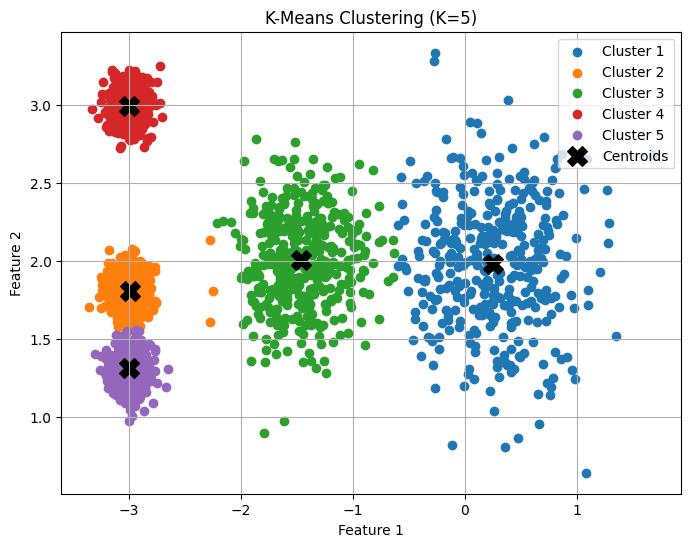

In [ ]:
#Problem 1 [2 points]
#Write Python code that implements the K-Means algorithm, as given above, to
#classify the data.

#Use  𝐾=5
#To reduce the sensitivity to initial conditions, your code should choose
#several (10) random initial conditions and then select the one that results in
#minimum total error.
#Provide the final cost,  𝐽 , and graph the final centroids.
import numpy as np
import matplotlib.pyplot as plt

def compute_cost(data, centroids, labels):
    #Compute total cost J (sum of squared distances).
    cost = 0
    for i in range(len(data)):
        cost += np.linalg.norm(data[i] - centroids[labels[i]])**2
    return cost

def kmeans(data, K=5, max_iters=100):
    #Perform K-Means clustering.#
    n_samples, n_features = data.shape
    # Randomly initialize centroids
    centroids = data[np.random.choice(n_samples, K, replace=False)]

    for _ in range(max_iters):
        # Assign each point to nearest centroid
        distances = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        # Compute new centroids
        new_centroids = np.array([data[labels == k].mean(axis=0) for k in range(K)])

        # Check for convergence
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    # Compute final cost
    final_cost = compute_cost(data, centroids, labels)
    return centroids, labels, final_cost

# Multiple random initializations
K = 5
best_cost = np.inf
best_centroids = None
best_labels = None

for i in range(10):
    centroids, labels, cost = kmeans(X, K)
    if cost < best_cost:
        best_cost = cost
        best_centroids = centroids
        best_labels = labels

print(f"Final minimum cost J = {best_cost:.4f}")

# Plotting the results
plt.figure(figsize=(8,6))
for k in range(K):
    cluster_points = X[best_labels == k]
    plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f'Cluster {k+1}')
plt.scatter(best_centroids[:,0], best_centroids[:,1], c='black', marker='X',
            s=200, label='Centroids')
plt.title(f"K-Means Clustering (K={K})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

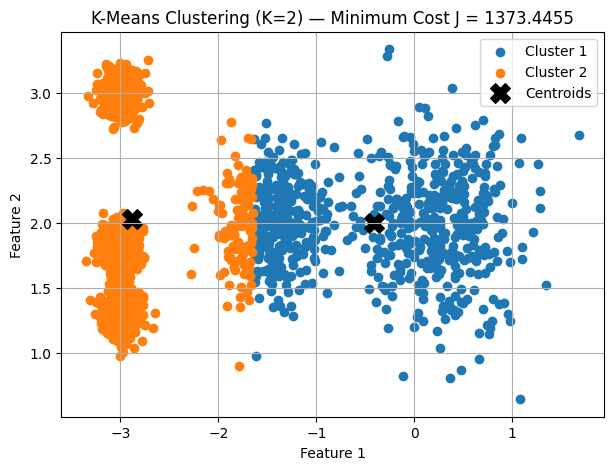

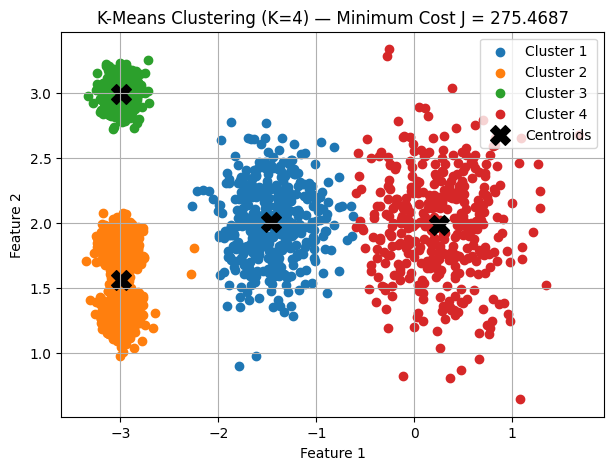

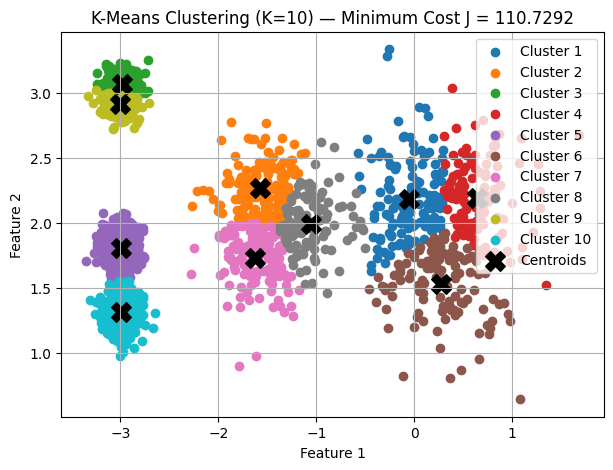

Summary of minimum costs:
K = 2: Minimum Cost J_K = 1373.4455
K = 4: Minimum Cost J_K = 275.4687
K = 10: Minimum Cost J_K = 110.7292


In [ ]:
#Problem 2 [3 points]
#Repeat what you did in Problem 1, except this time, vary the number of clusters.

#Use  𝐾=2 ,  𝐾=4 , and  𝐾=10 .
#To reduce the sensitivity to initial conditions, your code for each case should
#choose several (10) random initial conditions and then select the one that
#results in minimum total error.
#Provide the minimum cost,  𝐽𝐾 , for  𝐾=2,4,10  and graph the final centroids
#for each case.

Ks = [2, 4, 10]
results = {}

for K in Ks:
    best_cost = np.inf
    best_centroids = None
    best_labels = None

    # Run 10 random initializations
    for i in range(10):
        centroids, labels, cost = kmeans(X, K)
        if cost < best_cost:
            best_cost = cost
            best_centroids = centroids
            best_labels = labels

    results[K] = {'cost': best_cost, 'centroids': best_centroids, 'labels': best_labels}

    # Plotting each K
    plt.figure(figsize=(7,5))
    for k in range(K):
        cluster_points = X[best_labels == k]
        plt.scatter(cluster_points[:,0], cluster_points[:,1], label=f'Cluster {k+1}')
    plt.scatter(best_centroids[:,0], best_centroids[:,1], c='black', marker='X', s=200, label='Centroids')
    plt.title(f"K-Means Clustering (K={K}) — Minimum Cost J = {best_cost:.4f}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# Printing the summary table

print("Summary of minimum costs:")
for K, res in results.items():
    print(f"K = {K}: Minimum Cost J_K = {res['cost']:.4f}")